In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

plt.style.use('ggplot')
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'NanumGothic'

### 1층 체리부로 8/17 ~ 10/20 평균 픽셀  

In [5]:
# pixel 데이터 로드
chery_df = pd.read_csv("./data/Add_chery_pixel_data.csv")
chery_df.shape

(341, 8)

In [6]:
chery_df.columns = ['date', 'image_name','no_distortion_pixel_mean','no_distortion_count', 'distortion_pixel_mean','distortion_count', 'total_mean', 'total_count']
chery_df['date'] = chery_df['date'].astype('str')
chery_df['date'] = pd.to_datetime(chery_df['date'])
#chery_df['date'] = pd.to_datetime(chery_df["date"].dt.year.astype(str) + chery_df["date"].dt.month.astype(str) + chery_df["date"].dt.day.astype(str), format='%Y%m%d')

In [7]:
chery_pixel_sort_values_1f = chery_df.sort_values(by=["date"], ascending=[True])

In [8]:
# chery_pixel_sort_values = chery_pixel_sort_values.query('date >= "2021-08-23"')
# chery_pixel_sort_values = chery_pixel_sort_values.reset_index(drop=True)
chery_pixel_sort_values_1f['No'] = [ x[2] for x in chery_pixel_sort_values_1f.image_name.str.split('_')]
chery_pixel_sort_values_1f = chery_pixel_sort_values_1f.query('No == "H01"')


chery_pixel_sort_values_1f['timess'] = [ x[4] for x in chery_pixel_sort_values_1f.image_name.str.split('_')]
chery_pixel_sort_values_1f['timess'] = chery_pixel_sort_values_1f.timess.astype(int)
chery_pixel_sort_values_1f['times2'] = chery_pixel_sort_values_1f['timess'] // 1000000
#chery_pixel_sort_values_1f['dateTimess'] = pd.to_datetime(chery_pixel_sort_values_1f.timess, format='%Y%m%d%H%M%S')
#chery_pixel_sort_values_1f['moduleID'] = [ x[3] for x in chery_pixel_sort_values_1f.image_name.str.split('_')]
#chery_pixel_sort_values_1f = chery_pixel_sort_values_1f.query('moduleID == "0002"')

#chery_pixel_sort_values = chery_pixel_sort_values.groupby('times2')['no_distortion_pixel_mean'].agg(**{'no_distortion_pixel_mean':'mean'}).reset_index()
chery_pixel_sort_values_1f = chery_pixel_sort_values_1f.groupby(['times2'], as_index=False).mean()
#chery_pixel_sort_values = chery_pixel_sort_values[['times2', 'no_distortion_pixel_mean','No']]


# chery_pixel_sort_values = chery_pixel_sort_values.reset_index(drop=True)

chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20210816) ,'real_weight'] = 196
chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20210823),'real_weight'] = 378
chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20210830),'real_weight'] = 556

chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20210905),'real_weight'] = 827
chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20210913),'real_weight'] = 1093

chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20210920),'real_weight'] = 1272
chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20210927),'real_weight'] = 1379

chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20211004),'real_weight'] = 1553
chery_pixel_sort_values_1f.loc[(chery_pixel_sort_values_1f.times2 == 20211011),'real_weight'] = 1715

chery_pixel_sort_values_1f = chery_pixel_sort_values_1f.dropna(subset=['real_weight'],axis=0).reset_index(drop=True)
chery_pixel_sort_values_1f

OverflowError: Python int too large to convert to C long

In [9]:
# drop null
chery_pixel_sort_values_1f = chery_pixel_sort_values_1f[~chery_pixel_sort_values.no_distortion_pixel_mean.isnull()]

# drop outlier 
chery_pixel_sort_values_1f = chery_pixel_sort_values_1f[chery_pixel_sort_values.no_distortion_pixel_mean < 10000]

NameError: name 'chery_pixel_sort_values' is not defined

### 2층 체리부로 8/17 ~ 10/20 평균 픽셀

In [10]:
# pixel 데이터 로드
chery_df = pd.read_csv("./csv/Add_chery_pixel_data.csv")
chery_df.shape

chery_df.columns = ['date', 'image_name','no_distortion_pixel_mean','no_distortion_count', 'distortion_pixel_mean','distortion_count', 'total_mean', 'total_count']
chery_df['date'] = chery_df['date'].astype('str')
chery_df['date'] = pd.to_datetime(chery_df['date'])

chery_pixel_sort_values_2f = chery_df.sort_values(by=["date"], ascending=[True])


# chery_pixel_sort_values = chery_pixel_sort_values.query('date >= "2021-08-23"')
# chery_pixel_sort_values = chery_pixel_sort_values.reset_index(drop=True)
chery_pixel_sort_values_2f['No'] = [ x[2] for x in chery_pixel_sort_values_2f.image_name.str.split('_')]
chery_pixel_sort_values_2f = chery_pixel_sort_values_2f.query('No == "H02"')


chery_pixel_sort_values_2f['timess'] = [ x[4] for x in chery_pixel_sort_values_2f.image_name.str.split('_')]
chery_pixel_sort_values_2f['timess'] = chery_pixel_sort_values_2f.timess.astype(int)
chery_pixel_sort_values_2f['times2'] = chery_pixel_sort_values_2f['timess'] // 1000000
chery_pixel_sort_values_2f['dateTimess'] = pd.to_datetime(chery_pixel_sort_values_2f.timess, format='%Y%m%d%H%M%S')


#chery_pixel_sort_values = chery_pixel_sort_values.groupby('times2')['no_distortion_pixel_mean'].agg(**{'no_distortion_pixel_mean':'mean'}).reset_index()
chery_pixel_sort_values_2f = chery_pixel_sort_values_2f.groupby(['times2'], as_index=False).mean()
#chery_pixel_sort_values = chery_pixel_sort_values[['times2', 'no_distortion_pixel_mean','No']]

# chery_pixel_sort_values['moduleID'] = [ x[3] for x in chery_pixel_sort_values.image_name.str.split('_')]
# chery_pixel_sort_values = chery_pixel_sort_values.query('moduleID == "0002"')

# chery_pixel_sort_values = chery_pixel_sort_values.reset_index(drop=True)

# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20210819) ,'real_weight'] = 91.3
# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20210822),'real_weight'] = 157
# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20210829),'real_weight'] = 357

# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20210905),'real_weight'] = 540
# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20210912),'real_weight'] = 806

# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20210919),'real_weight'] = 1078
# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20210926),'real_weight'] = 1272

# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20211003),'real_weight'] = 1400
# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20211010),'real_weight'] = 1591
# chery_pixel_sort_values_2f.loc[(chery_pixel_sort_values_2f.times2 == 20211017),'real_weight'] = 1675

condition = (chery_pixel_sort_values_2f.times2 == 20210819) | (chery_pixel_sort_values_2f.times2 == 20210822) | \
(chery_pixel_sort_values_2f.times2 == 20210829) |(chery_pixel_sort_values_2f.times2 == 20210905) | \
(chery_pixel_sort_values_2f.times2 == 20210912) | (chery_pixel_sort_values_2f.times2 == 20210919) | \
(chery_pixel_sort_values_2f.times2 == 20210926) | (chery_pixel_sort_values_2f.times2 == 20211003) |\
(chery_pixel_sort_values_2f.times2 == 20211010) | (chery_pixel_sort_values_2f.times2 == 20211017)


#chery_pixel_sort_values_2f = chery_pixel_sort_values_2f.dropna(subset=['real_weight'],axis=0).reset_index(drop=True)
chery_pixel_sort_values_2f = chery_pixel_sort_values_2f[condition].reset_index(drop=True)
chery_pixel_sort_values_2f

FileNotFoundError: [Errno 2] No such file or directory: './csv/Add_chery_pixel_data.csv'

### Polynomial regression

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_target = chery_pixel_sort_values['real_weight']
X_data = chery_pixel_sort_values['no_distortion_pixel_mean']

X_train, X_test, y_train, y_test = train_test_split(chery_pixel_sort_values[['no_distortion_pixel_mean']], chery_pixel_sort_values['real_weight'], test_size=0.3, random_state=1)

poly_features  = PolynomialFeatures(degree=2, include_bias=False)
poly_features.fit_transform(X_train, y_train)

y_preds = poly_features.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0: .3f}, RMSE : {1:.3F}'.format(mse, rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

print('절편 값:', lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

NameError: name 'chery_pixel_sort_values' is not defined

In [827]:
# for i in range(6000, 6100) :
#     result = lr.predict(pd.DataFrame({'pixel' : [i]}))
#     print(f'pixel = {i}, result = {result}')

In [834]:
chery_pixel_sort_values_2f

,times2,no_distortion_pixel_mean,no_distortion_count,distortion_pixel_mean,distortion_count,total_mean,total_count,timess
0,20210819,1025.000000,1.000000,1283.000000,1.000000,1154.000000,2.000000,2.021082e+13
1,20210829,1723.666667,26.333333,1812.666667,14.666667,1757.666667,39.000000,2.021083e+13
2,20210905,2215.666667,47.666667,2343.666667,21.000000,2256.000000,40.000000,2.021091e+13
3,20210912,3135.666667,48.666667,3400.000000,21.000000,3203.000000,40.000000,2.021091e+13
4,20210919,4549.333333,26.666667,5064.333333,15.333333,4711.666667,35.333333,2.021092e+13
5,20210926,5548.666667,18.666667,6544.000000,14.666667,5988.000000,31.333333,2.021093e+13
6,20211003,5797.000000,12.666667,6979.666667,11.000000,6332.000000,23.666667,2.021100e+13
7,20211010,6792.000000,15.333333,7789.666667,6.333333,7105.000000,21.666667,2.021101e+13
8,20211017,7876.666667,13.000000,8073.000000,11.000000,8027.333333,24.000000,2.021102e+13


In [841]:
lr.predict(pd.DataFrame(chery_pixel_sort_values_2f['no_distortion_pixel_mean']))

array([ 202.97129672,  362.19634865,  474.32238712,  683.98896313,
       1006.16140837, 1233.90792825, 1290.50271054, 1517.26167046,
       1764.45552493])

In [ ]:
a = {'20210819': 91.3, '20210822' : 157, '20210829' : 357, '20210905' : 540, '20210912' : 806, '20210919' : 1078, \
    '20210926' : 1272, '20211003' : 1400, '20211010' : 1591, '20211017' : 1675}

In [842]:
chery_pixel_sort_values_2f['result'] = lr.predict(chery_pixel_sort_values_2f[['no_distortion_pixel_mean']])

<AxesSubplot:xlabel='times2'>

<Figure size 864x288 with 0 Axes>

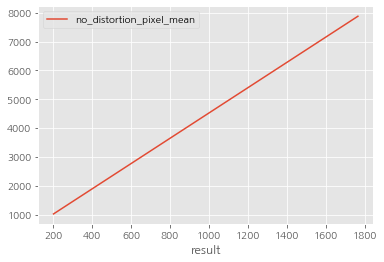

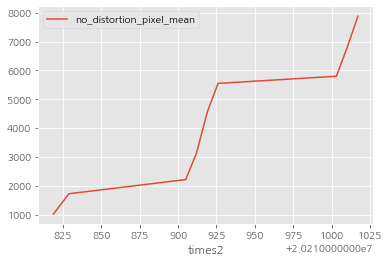

In [843]:
plt.figure(figsize=(12, 4))
chery_pixel_sort_values_2f.plot(x='result',y ='no_distortion_pixel_mean')
chery_pixel_sort_values_2f.plot(x='times2',y ='no_distortion_pixel_mean')

In [742]:
!jupyter nbconvert pixel_avg_linear.ipynb --template toc2

Traceback (most recent call last):
  File "/home/gate/.local/bin/jupyter-nbconvert", line 8, in <module>
    sys.exit(main())
  File "/home/gate/.local/lib/python3.9/site-packages/jupyter_core/application.py", line 264, in launch_instance
    return super(JupyterApp, cls).launch_instance(argv=argv, **kwargs)
  File "/home/gate/.local/lib/python3.9/site-packages/traitlets/config/application.py", line 846, in launch_instance
    app.start()
  File "/home/gate/.local/lib/python3.9/site-packages/nbconvert/nbconvertapp.py", line 361, in start
    self.convert_notebooks()
  File "/home/gate/.local/lib/python3.9/site-packages/nbconvert/nbconvertapp.py", line 521, in convert_notebooks
    raise ValueError(
ValueError: Please specify an output format with '--to <format>'.
The following formats are available: ['asciidoc', 'custom', 'html', 'latex', 'markdown', 'notebook', 'pdf', 'python', 'rst', 'script', 'slides', 'webpdf']
